# HCI Car Simulation_Data Analysis

In [428]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import re
import pandas as pd
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy.optimize import differential_evolution, minimize
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

from scripts import twoddynamics, oneddynamics, databuilder, readsubcategoryrating, intensity_calculation, demographics, plotter, optim, machinelearning


In [429]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [430]:
%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

# 0. Load data and write data dictionary

In [431]:
phase = "phaseI"
sub_nums = np.setdiff1d(np.arange(1,27,1), [12, 25])

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir = DATA_DIR / phase

df_phase = pd.read_csv(data_dir / "PhaseI_Block.csv")
df_pattern = pd.read_csv(data_dir / "RecommendationPatterns.csv")
stimuli_intensity_dict = intensity_calculation.intensity_calculation(data_dir / "recommendation_intensity_features.csv")

df_subcategory_rating = pd.read_csv(data_dir / "Rating_subcategory.csv")
df_subcategory_rating = readsubcategoryrating.format(df_subcategory_rating)

df_subject_prior = pd.read_csv(DATA_DIR / "sub_prior.csv")
df_subject_prior = readsubcategoryrating.format_prior(df_subject_prior)

df_demographics = pd.read_csv(DATA_DIR / "demographics.csv")
df_demographics = readsubcategoryrating.format_demographics(df_demographics)


=== driving experience ===
mean   : 5.976
median : 5.000
std    : 5.475
n      : 25

=== age ===
mean   : 25.240
median : 25.000
std    : 4.075
n      : 25

=== gender ===
                           count  ratio
gender                                 
male                          17   0.68
female                         6   0.24
non-binary / third gender      1   0.04
prefer not to say              1   0.04

=== nationality ===
                  count  ratio
nationality                   
china                16   0.64
united states         5   0.20
bangladeshi           1   0.04
turkey                1   0.04
israel                1   0.04
iranian american      1   0.04

=== driver license ===
                count  ratio
driver license              
yes                25    1.0

=== education level ===
                 count  ratio
education level              
undergraduate       19   0.76
master's             6   0.24

=== driving frequency ===
                   count  ratio
dri

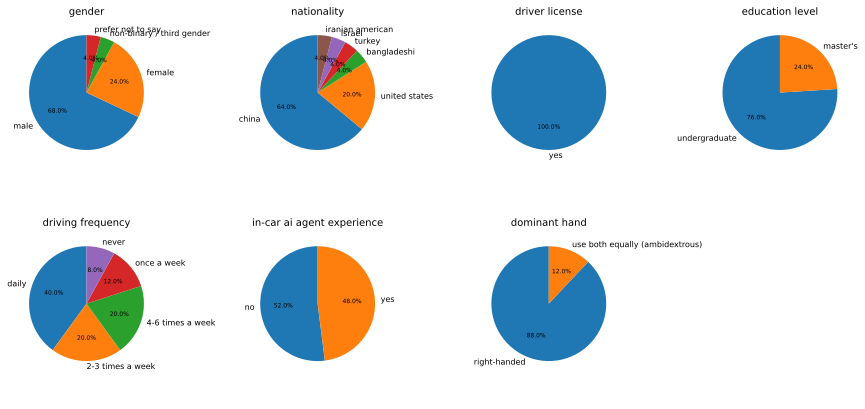

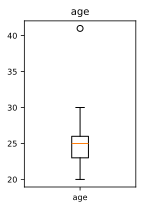

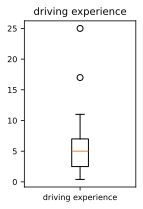

In [432]:
demographics_results = demographics.summarize(df_demographics)
demographics.print_report(demographics_results)
demographics.plot_demographics(df_demographics)

In [433]:
print(stimuli_intensity_dict)

{10101: 0.23818181818181813, 10201: 0.2, 10301: 0.369090909090909, 10401: 0.39636363636363636, 10501: 0.41999999999999993, 20101: 0.20727272727272728, 20102: 0.0, 20103: 0.13090909090909092, 20104: 0.2872727272727273, 20105: 0.11818181818181817, 20201: 0.369090909090909, 20301: 0.14363636363636365, 20401: 0.40727272727272723, 20501: 0.5272727272727272}


In [434]:
data_dict = defaultdict(dict)

for sub in sub_nums:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 3, f"sub{sub} has more than 3 folders"

    for j, sub_dir in enumerate(sub_dirs):
        block = j + 4 if sub % 2 == 0 else j + 1
        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating[(df_subcategory_rating["sub_id"] == sub) & (df_subcategory_rating["block_id"] == block)]

        scene_key = f"scene_{row['SceneID']}"

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        data_dict[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

In [435]:
def build_trial_level_df(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            if scene_key == "scene_4":
                verison = "personalized"
                scene_key = "scene_3"
            elif scene_key == "scene_5":
                verison = "personified"
                scene_key = "scene_3"
            else:
                verison = "default"

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")

            df["accept_bin"] = (df["reaction"] == "accept").astype(int)

            for _, row in df.iterrows():
                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "version": verison,
                    "driving": driving,
                    "type": int(row["type"]),
                    "accept": row["accept_bin"]
                })

    return pd.DataFrame(records)

df_trial = build_trial_level_df(data_dict)

# 1. Mixed Effect Modeling
## 1.1 LMM treat sub as random intercept

In [436]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ C(driving, Sum) * C(scene, Sum) * C(type, Sum)",
    df_trial,
    groups=df_trial["sub"]
)

result = model.fit()
print(result.summary())

def test_effect(result, terms):
    print("\nTesting:", terms)
    print(result.wald_test(terms))

# main effects
test_effect(result, "C(driving, Sum)[S.auto] = 0")
test_effect(result, "C(type, Sum)[S.1] = 0")
test_effect(result, """
C(scene, Sum)[S.scene_1] = 0,
C(scene, Sum)[S.scene_2] = 0
""")

                                    Mixed Linear Model Regression Results
Model:                              MixedLM                   Dependent Variable:                   accept   
No. Observations:                   722                       Method:                               REML     
No. Groups:                         24                        Scale:                                0.1953   
Min. group size:                    30                        Log-Likelihood:                       -477.3342
Max. group size:                    31                        Converged:                            Yes      
Mean group size:                    30.1                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## 1.1 Treat Type Independently

In [437]:
for t in [1, 2]:
    df_sub = df_trial[df_trial["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ C(driving, Sum) * C(scene, Sum)",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())

    # ===== main effects =====
    print("\n-- Main Effects --")
    
    # driving
    print("\nDriving effect:")
    print(result.wald_test("C(driving, Sum)[S.auto] = 0"))
    
    # scene（joint test）
    print("\nScene effect:")
    print(result.wald_test("""
        C(scene, Sum)[S.scene_1] = 0,
        C(scene, Sum)[S.scene_2] = 0
    """))
    
    # ===== interaction =====
    print("\n-- Interaction --")
    
    print("\nDriving × Scene:")
    print(result.wald_test("""
        C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_1] = 0,
        C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_2] = 0
    """))


=== Type 1 ===
                           Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             accept   
No. Observations:             360                 Method:                         REML     
No. Groups:                   24                  Scale:                          0.1725   
Min. group size:              15                  Log-Likelihood:                 -214.5998
Max. group size:              15                  Converged:                      Yes      
Mean group size:              15.0                                                         
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                         0.753    0.030 25.211 0.000  0.694  0.811

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## 1.2 LMM treat sub as random slope

In [438]:
model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"],
    re_formula="~type"
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          722              Method:                      REML     
No. Groups:                24               Scale:                       0.1942   
Min. group size:           30               Log-Likelihood:              -463.7539
Max. group size:           31               Converged:                   Yes      
Mean group size:           30.1                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.000    0.129  7.766 0.000  0.748  1.252
driving[T.manual]                       -0.167    0.182 -0.915 0.360 -0.524  0.190
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


# 2. Acceptance rate description

In [439]:
def extract_reaction_stats(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            if scene_key == "scene_4":
                version = "personalized"
                scene_key = "scene_3"
            elif scene_key == "scene_5":
                version = "personified"
                scene_key = "scene_3"
            else:
                version = "default"

            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")
            df["pattern"] = df["current_encode_id"].astype(str)
            df["type_sub"] = df["pattern"].str[1:3]

            for t in ["1", "2"]:
                sub_df = df[df["type"] == t]
                if len(sub_df) == 0:
                    continue

                total = len(sub_df)
                counts = sub_df["reaction"].value_counts()

                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "version": version,
                    "driving": driving,
                    "type": int(t),
                    "accept": counts.get("accept", 0)/total,
                    "reject": counts.get("reject", 0)/total,
                    "ignore": counts.get("ignore", 0)/total,
                })

    return pd.DataFrame(records)

In [440]:
import seaborn as sns
import matplotlib.pyplot as plt

type_palette = {
    1: "#1D9CFF",
    2: "#FFA51C",
}

driving_mode_palette = {
    'auto': "#651DFF",
    'manual': "#FFA51C",
}

def plot_scene_box(df):
    for metric in ["accept", "reject", "ignore"]:
        for t in [1, 2]:
            plt.figure(figsize=(8,5))
            sns.boxplot(
                data=df[df["type"]==t],
                x="scene",
                y=metric,
                hue="driving"
            )
            plt.title(f"{metric} (Type {t}) across scenes")
            plt.xticks(rotation=30)
            plt.show()

def plot_scene_facet(df):
    for metric in ["accept", "reject", "ignore"]:
        g = sns.catplot(
            data=df,
            x="scene",
            y=metric,
            hue="driving",
            col="type",
            kind="box",
            height=4,
            aspect=1.2
        )
        g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=30)
        plt.show()

def plot_type_facet(df, col="scene"):
    for metric in ["accept"]:
        g = sns.catplot(
            data=df,
            x="type",
            y=metric,
            hue="type",
            palette=type_palette,
            col=col,
            kind="bar",
            errorbar="se",
            height=3,
            aspect=0.75,
            legend=False,
        )
        
        # g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        g.set_xticklabels(["type 1", "type 2"])
        g.set_axis_labels("", f"{metric} ratio")

        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=0)
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))
        
        plt.show()

In [441]:
from scipy.stats import mannwhitneyu, wilcoxon

def summarize_scene(df):
    summary = df.groupby(["scene","driving","type"]).agg(
        accept_mean=("accept","mean"),
        reject_mean=("reject","mean"),
        ignore_mean=("ignore","mean"),
        n=("sub","count")
    ).reset_index()

    print(summary)
    return summary

from scipy.stats import mannwhitneyu

def test_driving_per_scene(df):
    print("\n=== Driving effect per scene ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for scene in df["scene"].unique():
            for t in [1,2]:
                sub_df = df[(df["scene"]==scene) & (df["type"]==t)]

                g1 = sub_df[sub_df["driving"]=="manual"][metric]
                g2 = sub_df[sub_df["driving"]=="auto"][metric]

                if len(g1)>0 and len(g2)>0:
                    _, p = mannwhitneyu(g1, g2)
                    print(f"{scene}, type{t}: p={p:.4f}")

from scipy.stats import friedmanchisquare

def test_scene_effect(df):
    print("\n=== Scene effect ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index="sub",
                columns="scene",
                values=metric
            ).dropna()

            if pivot.shape[1] >= 3:
                stat, p = friedmanchisquare(*[pivot[c] for c in pivot.columns])
                print(f"type{t}: p={p:.4f}")

def test_interaction_proxy(df):
    print("\n=== Interaction proxy (Δscene effect between driving) ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index=["sub","driving"],
                columns="scene",
                values=metric
            ).dropna()

            pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

            manual = pivot[pivot.index.get_level_values("driving")=="manual"]["range"]
            auto   = pivot[pivot.index.get_level_values("driving")=="auto"]["range"]

            if len(manual)>0 and len(auto)>0:
                _, p = mannwhitneyu(manual, auto)
                print(f"type{t}: p={p:.4f}")

from scipy.stats import mannwhitneyu

def test_scene_type_diff(df):
    print("\n=== Type1 vs Type2 difference within each scene ===")

    for metric in ["accept", "reject", "ignore"]:
        print(f"\n--- {metric} ---")

        for scene in sorted(df["scene"].unique()):
            scene_df = df[df["scene"] == scene]

            type1 = scene_df.loc[scene_df["type"] == 1, metric].dropna()
            type2 = scene_df.loc[scene_df["type"] == 2, metric].dropna()

            if len(type1) > 0 and len(type2) > 0:
                stat, p = mannwhitneyu(type1, type2, alternative="two-sided")
                print(
                    f"{scene}: "
                    f"type1(n={len(type1)}, mean={type1.mean():.3f}, median={type1.median():.3f}) | "
                    f"type2(n={len(type2)}, mean={type2.mean():.3f}, median={type2.median():.3f}) | "
                    f"U={stat:.3f}, p={p:.4f}"
                )
            else:
                print(f"{scene}: insufficient data")

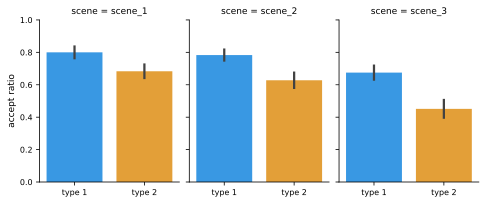

      scene driving  type  accept_mean  reject_mean  ignore_mean   n
0   scene_1    auto     1     0.816667     0.083333     0.100000  12
1   scene_1    auto     2     0.633333     0.316667     0.050000  12
2   scene_1  manual     1     0.783333     0.100000     0.116667  12
3   scene_1  manual     2     0.733333     0.166667     0.100000  12
4   scene_2    auto     1     0.816667     0.116667     0.066667  12
5   scene_2    auto     2     0.566667     0.366667     0.066667  12
6   scene_2  manual     1     0.750000     0.183333     0.066667  12
7   scene_2  manual     2     0.688889     0.230556     0.080556  12
8   scene_3    auto     1     0.783333     0.200000     0.016667  12
9   scene_3    auto     2     0.416667     0.516667     0.066667  12
10  scene_3  manual     1     0.566667     0.316667     0.116667  12
11  scene_3  manual     2     0.486111     0.347222     0.166667  12

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_1: type1(n=24, mean=0.800, m

In [442]:
df_stats = extract_reaction_stats(data_dict)

# plot_scene_facet(df_stats)
plot_type_facet(df_stats)

summary = summarize_scene(df_stats)

# test_driving_per_scene(df_stats)
# test_scene_effect(df_stats)
# test_interaction_proxy(df_stats)
test_scene_type_diff(df_stats)

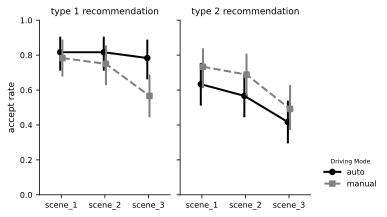

In [443]:
df_trial["driving"] = df_trial["driving"].astype("category")
df_trial["scene"] = df_trial["scene"].astype("category")
df_trial["type"] = df_trial["type"].astype("category")

# plt.figure(figsize=(3,3))

g = sns.catplot(
    data=df_trial,
    x="scene",
    y="accept",
    hue="driving",
    col="type",
    kind="point",
    dodge=True,
    errorbar=('ci', 95),
    height=3,
    aspect=0.6,
    palette=["black", "gray"],
    markers=["o", "s"],
    linestyles=["-", "--"],
    linewidth = 2.0,
)

g.set_axis_labels("", "accept rate")
g.set_titles("type {col_name} recommendation")
g._legend.set_bbox_to_anchor((1.0, 0.1))
g._legend.set_loc("lower left")
g._legend.set_title("Driving Mode")
# g.fig.suptitle(
#     "Accept Rate by Scene, Driving Mode, and Type",
#     y=1.0,
#     ha='center'
# )

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

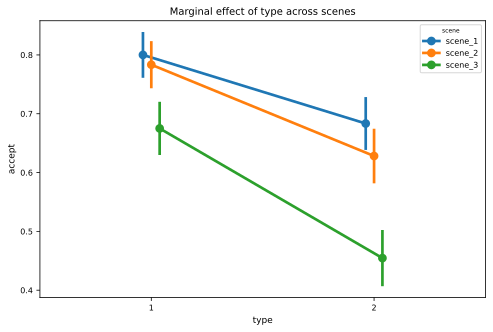

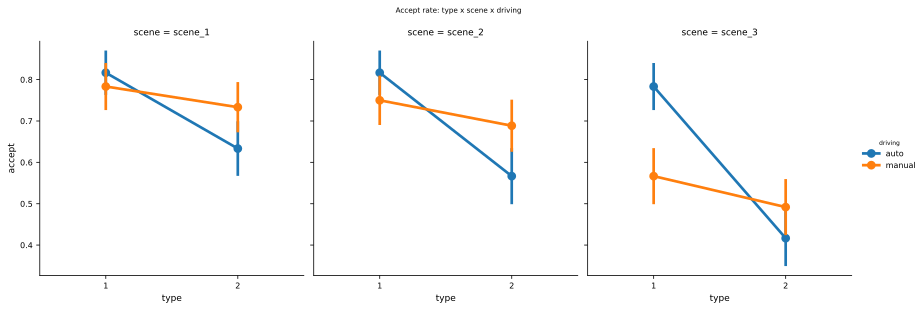

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1614/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1614/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1614/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain

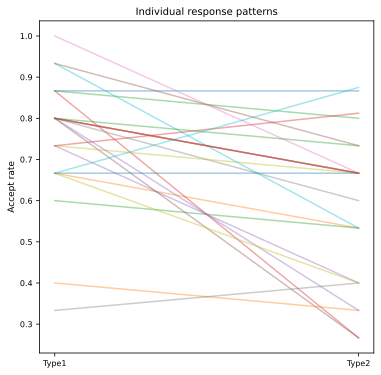

In [444]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="scene",
    dodge=True,
    errorbar="se"
)

plt.title("Marginal effect of type across scenes")
plt.show()

g = sns.catplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="driving",
    col="scene",
    kind="point",
    errorbar="se",
    height=4,
    aspect=1,
)

g.fig.suptitle("Accept rate: type x scene x driving", y=1.05)
plt.show()

plt.figure(figsize=(6,6))

for sub in df_trial["sub"].unique():
    sub_df = df_trial[df_trial["sub"]==sub]
    pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")

    plt.plot([1,2], pivot.values.flatten(), alpha=0.4)

plt.xticks([1,2], ["Type1", "Type2"])
plt.ylabel("Accept rate")
plt.title("Individual response patterns")
plt.show()

## 3. Subject clustering

In [445]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot.columns = ["accept_type1", "accept_type2"]
pivot["diff"] = pivot["accept_type1"] - pivot["accept_type2"]

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1614/1223868461.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


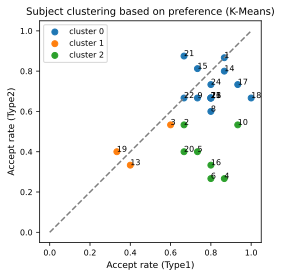

In [446]:
from sklearn.cluster import KMeans

X = pivot[["accept_type1", "accept_type2"]].values

kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
pivot["cluster"] = kmeans.labels_

plt.figure(figsize=(4,4))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"]==c]
    plt.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )
    for idx, row in sub_df.iterrows():
        plt.text(
            row["accept_type1"],
            row["accept_type2"],
            str(idx),
            fontsize=8
        )

plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("Accept rate (Type1)")
plt.ylabel("Accept rate (Type2)")
# plt.xticks(np.linspace(0, 1, 11))
# plt.yticks(np.linspace(0, 1, 11))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Subject clustering based on preference (K-Means)")
plt.show()

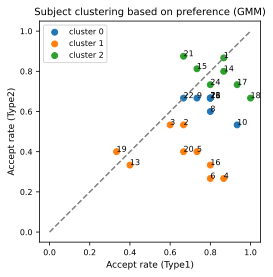

In [447]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

X = pivot[["accept_type1", "accept_type2"]].values

gmm = GaussianMixture(n_components=3, random_state=42)
pivot["cluster"] = gmm.fit_predict(X)

fig, ax = plt.subplots(figsize=(4, 4))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"] == c]
    ax.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )
    for idx, row in sub_df.iterrows():
        plt.text(
            row["accept_type1"],
            row["accept_type2"],
            str(idx),
            fontsize=8
        )

ax.set_xlabel("Accept rate (Type1)")
ax.set_ylabel("Accept rate (Type2)")
ax.set_aspect("equal", adjustable="box")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.legend()
ax.set_title("Subject clustering based on preference (GMM)")

plt.show()

In [448]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot["diff"] = pivot[1] - pivot[2]
print(pivot)

type         1         2      diff
sub                               
1     0.866667  0.866667  0.000000
2     0.666667  0.533333  0.133333
3     0.600000  0.533333  0.066667
4     0.866667  0.266667  0.600000
5     0.733333  0.400000  0.333333
6     0.800000  0.266667  0.533333
7     0.800000  0.666667  0.133333
8     0.800000  0.600000  0.200000
9     0.733333  0.666667  0.066667
10    0.933333  0.533333  0.400000
11    0.800000  0.666667  0.133333
13    0.400000  0.333333  0.066667
14    0.866667  0.800000  0.066667
15    0.733333  0.812500 -0.079167
16    0.800000  0.333333  0.466667
17    0.933333  0.733333  0.200000
18    1.000000  0.666667  0.333333
19    0.333333  0.400000 -0.066667
20    0.666667  0.400000  0.266667
21    0.666667  0.875000 -0.208333
22    0.666667  0.666667  0.000000
23    0.800000  0.666667  0.133333
24    0.800000  0.733333  0.066667
26    0.800000  0.666667  0.133333


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1614/1211643864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


# 4. Per-reaction modeling

For each reaction, we aggregate trial-level features into the following groups.

---

### Meta

- `sub_id`: subject ID (`int`)
- `scene_id`: scene ID (`int`)
- `mode`: driving mode (`int`)
- `recommendation`: recommendation code (`int`, 5 digits)
- `recommendation_category`: recommendation category (`int`, 1 digit)
- `recommendation_subcategory`: recommendation subcategory (`int`, 3 digits)

---

### Prior

These variables describe the participant’s baseline tendency and behavioral state before the current recommendation.

- `subject_prior_accept_prob_subcategory`: subject-level prior probability of accepting this recommendation subcategory (`float`)
- `mean_steering_input`: mean steering input (`float`)
- `var_steering_input`: variance of steering input (`float`)
- `mean_throttle_input`: mean throttle input (`float`)
- `var_throttle_input`: variance of throttle input (`float`)

---

### Scenario

These variables describe the current recommendation and the driving context around the reaction.

- `intensity`: intensity of the recommendation (`float`)
- `coherence`: coherence of the recommendation (`float`)
- `mean_steering_input_zscore_pre2s`: mean steering input z-score in the 2 s pre-reaction window (`float`)
- `mean_throttle_input_zscore_pre2s`: mean throttle input z-score in the 2 s pre-reaction window (`float`)

---

### Reaction

These variables describe the behavioral response to the recommendation.

- `accept`: whether the recommendation was accepted (`bool`)
- `reaction_time_ms`: reaction time in milliseconds (`float`)
- `mean_steering_input_zscore_post5s`: mean steering input z-score in the 5 s post-reaction window (`float`)
- `mean_throttle_input_zscore_post5s`: mean throttle input z-score in the 5 s post-reaction window (`float`)

---

### Evaluation

These variables describe the participant’s subjective evaluation after the reaction.

- `disturbance`: perceived disturbance (`float`)
- `satisfaction`: subjective satisfaction (`float`)
- `appropriateness`: perceived appropriateness (`float`)

---

## Dynamic Modeling Goal

We build a dynamical decision model that takes **prior** and **scenario** variables as inputs to predict whether a recommendation is **accepted**.

The model is designed to capture the competition between latent **accept** and **reject** decision states over time.

---

## Modeling Assumption

We assume that the biological time constant of the decision dynamics is the same across participants.

In other words:

- the accept-state time constant is shared across subjects
- the reject-state time constant is shared across subjects

This means that individual differences are modeled mainly through:

- prior acceptance tendency
- scenario-dependent inputs
- reaction-specific context

rather than through subject-specific intrinsic time constants.


In [449]:
df_reaction = databuilder.build_per_reaction_df(
    data_dict,
    intensity_dict = stimuli_intensity_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
    # df_subject_prior=df_subject_prior,
)

# print(df_reaction["prior_mean_throttle_input"].head())

reaction_data_dict = databuilder.build_per_reaction_data_dict(df_reaction)

## 4.1 Subcategory Disturbance, Satisfaction and Appropriateness

In [450]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

df = df_reaction.copy()

df["scene_id"] = df["scene_id"].astype("category")
df["mode"] = df["mode"].astype("category")
df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")
df["sub_id"] = df["sub_id"].astype("category")

metrics = ["appropriateness", "disturbance", "satisfaction"]

In [451]:
for col in ["recommendation_subcategory", "scene_id", "mode"]+metrics:
    print(col, df[col].isna().sum(), df[col].dtype)

recommendation_subcategory 0 category
scene_id 0 category
mode 0 category
appropriateness 0 int16
disturbance 0 int16
satisfaction 0 int16


In [452]:
overall_results = []

for metric in metrics:
    formula = f"{metric} ~ C(recommendation_subcategory, Sum) * scene_id * mode"
    model_all = smf.mixedlm(
        formula,
        df,
        groups=df["sub_id"]
    ).fit(reml=False)

    print("\n" + "="*80)
    print(f"OVERALL MODEL FOR {metric}")
    print("="*80)
    print(model_all.summary())

    coef_table = pd.DataFrame({
        "term": model_all.params.index,
        "coef": model_all.params.values,
        "pval": model_all.pvalues.values
    })
    coef_table["metric"] = metric
    overall_results.append(coef_table)
    terms = [
        t for t in model_all.params.index
        if "C(recommendation_subcategory, Sum)" in t
        and ":" not in t
    ]

    hypothesis = ", ".join([f"{t} = 0" for t in terms])

    print(model_all.wald_test(hypothesis))

overall_results_df = pd.concat(overall_results, ignore_index=True)


OVERALL MODEL FOR appropriateness
                                      Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  appropriateness
No. Observations:                    722                      Method:                              ML             
No. Groups:                          24                       Scale:                               2.1074         
Min. group size:                     30                       Log-Likelihood:                      -1314.5462     
Max. group size:                     31                       Converged:                           Yes            
Mean group size:                     30.1                                                                         
------------------------------------------------------------------------------------------------------------------
                                                                        Coef.  Std.E

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, 

In [453]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# =========================================================
# 0) 基础准备
# =========================================================
df = df.copy()

if not isinstance(df["recommendation_subcategory"].dtype, pd.CategoricalDtype):
    df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")

subcat_levels = list(df["recommendation_subcategory"].cat.categories)


# =========================================================
# 1) 每个 subcategory 内部:
#    metric ~ scene_id * mode
# =========================================================
per_subcat_results = []
per_subcat_models = {}

for subcat in subcat_levels:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ scene_id * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Per-subcat model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)


# =========================================================
# 2) FDR by (metric, term)
# =========================================================
def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    if len(df_out) == 0:
        return df_out

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for _, idx in grouped.groups.items():
        idx = list(idx)
        pvals = df_out.loc[idx, p_col].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = np.array(idx)
            df_out.loc[idx_arr[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)


# =========================================================
# 3) 汇总 scene / mode / interaction
# =========================================================
summary_rows = []

for subcat in subcat_levels:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        scene_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            ~df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        mode_terms = df_tmp[
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "scene_min_p": scene_terms["pval"].min() if len(scene_terms) else np.nan,
            "scene_min_p_fdr": scene_terms["pval_fdr"].min() if len(scene_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)


# =========================================================
# 4) 全局模型:
#    metric ~ C(recommendation_subcategory, Sum) + scene_id + mode
#    计算每个 subcategory 相对 overall mean 的显著性
# =========================================================
def parse_sum_term_level(term):
    # e.g. C(recommendation_subcategory, Sum)[S.101] -> "101"
    if "[S." in term:
        return term.split("[S.")[-1].rstrip("]")
    return None


def cast_level_to_match_categories(level_str, categories):
    if len(categories) == 0:
        return level_str

    first = categories[0]

    try:
        if isinstance(first, (int, np.integer)):
            return int(level_str)
        elif isinstance(first, (float, np.floating)):
            return float(level_str)
        else:
            return str(level_str)
    except Exception:
        return level_str


def wald_pvalue(test_obj):
    return float(np.asarray(test_obj.pvalue).reshape(-1)[0])


def get_subcategory_vs_mean_from_global_model(model, subcat_levels):
    params = model.params.index.tolist()

    main_terms = [
        t for t in params
        if "C(recommendation_subcategory, Sum)" in t and ":" not in t
    ]

    if len(main_terms) == 0:
        raise ValueError("No main-effect sum-coded subcategory terms found in model.")

    results = []
    mapped_levels = []

    # -------- 显式显示的 levels --------
    for term in main_terms:
        lvl_raw = parse_sum_term_level(term)
        lvl = cast_level_to_match_categories(lvl_raw, subcat_levels)
        mapped_levels.append(lvl)

        # 用 wald_test，不用 t_test
        test = model.wald_test(f"{term} = 0", scalar=True)

        results.append({
            "subcategory": lvl,
            "subcat_coef": model.params[term],
            "subcat_p": wald_pvalue(test)
        })

    # -------- 最后一个隐含 level --------
    # sum coding 下最后一个 level = -(前面所有level之和)
    missing_levels = [lvl for lvl in subcat_levels if lvl not in mapped_levels]

    if len(missing_levels) == 1:
        last_level = missing_levels[0]

        expr = " + ".join(main_terms) + " = 0"
        test = model.wald_test(expr, scalar=True)

        results.append({
            "subcategory": last_level,
            "subcat_coef": -sum(model.params[t] for t in main_terms),
            "subcat_p": wald_pvalue(test)
        })

    elif len(missing_levels) > 1:
        raise ValueError(f"More than one missing level inferred: {missing_levels}")

    res_df = pd.DataFrame(results)

    res_df["subcategory"] = pd.Categorical(
        res_df["subcategory"],
        categories=subcat_levels,
        ordered=True
    )
    res_df = res_df.sort_values("subcategory").reset_index(drop=True)
    res_df["subcategory"] = res_df["subcategory"].astype(object)

    return res_df


global_subcat_effect_rows = []
global_models = {}
global_factor_tests = []

for metric in metrics:
    formula = f"{metric} ~ C(recommendation_subcategory, Sum) + scene_id + mode"

    try:
        print(f"Fitting global model for metric={metric} ...")

        model_all = smf.mixedlm(
            formula,
            df,
            groups=df["sub_id"]
        ).fit(reml=False)

        global_models[metric] = model_all

        # ---- 整体 subcategory 主效应 joint test ----
        main_terms = [
            t for t in model_all.params.index
            if "C(recommendation_subcategory, Sum)" in t and ":" not in t
        ]
        joint_expr = ", ".join([f"{t} = 0" for t in main_terms])
        joint_test = model_all.wald_test(joint_expr, scalar=True)

        global_factor_tests.append({
            "metric": metric,
            "subcategory_overall_chi2": float(np.asarray(joint_test.statistic).reshape(-1)[0]),
            "subcategory_overall_p": wald_pvalue(joint_test),
            "subcategory_df": len(main_terms)
        })

        # ---- 每个 subcategory vs overall mean ----
        subcat_effect_df = get_subcategory_vs_mean_from_global_model(
            model_all,
            subcat_levels=subcat_levels
        )
        subcat_effect_df["metric"] = metric

        global_subcat_effect_rows.append(subcat_effect_df)

    except Exception as e:
        print(f"Global model failed for metric={metric}: {e}")


if len(global_subcat_effect_rows) > 0:
    global_subcat_effect_df = pd.concat(global_subcat_effect_rows, ignore_index=True)
else:
    global_subcat_effect_df = pd.DataFrame(
        columns=["subcategory", "subcat_coef", "subcat_p", "metric"]
    )

global_factor_tests_df = pd.DataFrame(global_factor_tests)


# =========================================================
# 5) FDR for subcategory-vs-mean
# =========================================================
global_subcat_effect_df["subcat_p_fdr"] = np.nan

if len(global_subcat_effect_df) > 0:
    for metric in metrics:
        idx = global_subcat_effect_df["metric"] == metric
        pvals = global_subcat_effect_df.loc[idx, "subcat_p"].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = global_subcat_effect_df.index[idx].to_numpy()
            global_subcat_effect_df.loc[idx_arr[mask], "subcat_p_fdr"] = corrected


# =========================================================
# 6) merge
# =========================================================
summary_df = summary_df.merge(
    global_subcat_effect_df[
        ["subcategory", "metric", "subcat_coef", "subcat_p", "subcat_p_fdr"]
    ],
    on=["subcategory", "metric"],
    how="left"
)

summary_df = summary_df.merge(
    global_factor_tests_df,
    on="metric",
    how="left"
)

summary_df = summary_df.sort_values(["metric", "subcategory"]).reset_index(drop=True)


# =========================================================
# 7) significance flags
# =========================================================
alpha = 0.05
summary_df["scene_sig"] = summary_df["scene_min_p_fdr"] < alpha
summary_df["mode_sig"] = summary_df["mode_min_p_fdr"] < alpha
summary_df["interaction_sig"] = summary_df["interaction_min_p_fdr"] < alpha
summary_df["subcat_vs_mean_sig"] = summary_df["subcat_p_fdr"] < alpha
summary_df["subcategory_overall_sig"] = summary_df["subcategory_overall_p"] < alpha


# =========================================================
# 8) 输出
# =========================================================
# print("\nglobal_factor_tests_df:")
# print(global_factor_tests_df)

# print("\nglobal_subcat_effect_df:")
# print(global_subcat_effect_df.head())

# print("\nsummary_df:")
# print(summary_df.head())

summary_df

Fitting global model for metric=appropriateness ...
Fitting global model for metric=disturbance ...
Fitting global model for metric=satisfaction ...


,subcategory,metric,scene_min_p,scene_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr,subcat_coef,subcat_p,subcat_p_fdr,subcategory_overall_chi2,subcategory_overall_p,subcategory_df,scene_sig,mode_sig,interaction_sig,subcat_vs_mean_sig,subcategory_overall_sig
0,101,appropriateness,3.751876e-01,5.620891e-01,0.227142,0.757141,0.059947,0.299735,1.322124,3.159754e-14,3.159754e-13,174.681322,6.525248e-33,9,False,False,False,True,True
1,102,appropriateness,5.491221e-02,2.238071e-01,1.000000,1.000000,0.415413,0.593447,0.961013,3.426629e-08,1.142210e-07,174.681322,6.525248e-33,9,False,False,False,True,True
2,103,appropriateness,4.395293e-01,5.620891e-01,0.360351,0.900879,0.218766,0.447805,0.599902,5.718616e-04,9.531027e-04,174.681322,6.525248e-33,9,False,False,False,True,True
3,104,appropriateness,1.319028e-01,1.943592e-01,0.051150,0.511498,0.110035,0.353993,0.461013,8.117954e-03,1.159708e-02,174.681322,6.525248e-33,9,False,False,False,True,True
4,105,appropriateness,4.269234e-06,4.269234e-05,0.808633,1.000000,0.057893,0.299735,-0.788987,5.888801e-06,1.472200e-05,174.681322,6.525248e-33,9,True,False,False,True,True
5,201,appropriateness,4.241921e-04,2.120961e-03,0.813987,1.000000,0.530148,0.662685,-0.288005,9.424215e-02,1.047135e-01,174.681322,6.525248e-33,9,True,False,False,False,True
6,202,appropriateness,1.224041e-01,1.943592e-01,0.797985,1.000000,0.395561,0.662685,-0.386209,2.658188e-02,3.322734e-02,174.681322,6.525248e-33,9,False,False,False,True,True
7,203,appropriateness,1.360514e-01,1.943592e-01,0.917239,1.000000,0.223903,0.447805,-0.747320,1.777950e-05,3.555900e-05,174.681322,6.525248e-33,9,False,False,False,True,True
8,204,appropriateness,7.859332e-02,1.943592e-01,0.104934,0.524669,0.141597,0.353993,-1.108432,1.958190e-10,9.790950e-10,174.681322,6.525248e-33,9,False,False,False,True,True
9,205,appropriateness,2.264361e-02,7.547871e-02,0.906258,1.000000,0.132498,0.447805,-0.025098,8.854112e-01,8.854112e-01,174.681322,6.525248e-33,9,False,False,False,False,True


In [454]:
from itertools import combinations
from scipy.stats import ttest_rel

pairwise_rows = []

for metric in metrics:
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    wide = agg.pivot(index="sub_id", columns="recommendation_subcategory", values=metric)

    for a, b in combinations(wide.columns, 2):
        paired = wide[[a, b]].dropna()
        if len(paired) >= 2:
            stat, pval = ttest_rel(paired[a], paired[b])
            pairwise_rows.append({
                "metric": metric,
                "subcat_a": a,
                "subcat_b": b,
                "n_subjects": len(paired),
                "mean_a": paired[a].mean(),
                "mean_b": paired[b].mean(),
                "mean_diff": (paired[a] - paired[b]).mean(),
                "pval": pval
            })

pairwise_df = pd.DataFrame(pairwise_rows)

# FDR per metric
pairwise_df["pval_fdr"] = np.nan
for metric in metrics:
    idx = pairwise_df["metric"] == metric
    if idx.sum() > 0:
        pairwise_df.loc[idx, "pval_fdr"] = multipletests(
            pairwise_df.loc[idx, "pval"],
            method="fdr_bh"
        )[1]

pairwise_df = pairwise_df.sort_values(["metric", "pval_fdr"])
pairwise_df.head(20)

,metric,subcat_a,subcat_b,n_subjects,mean_a,mean_b,mean_diff,pval,pval_fdr
3,appropriateness,101,105,24,6.458333,4.347222,2.111111,1.163566e-07,0.000002
6,appropriateness,101,203,24,6.458333,4.388889,2.069444,8.041874e-08,0.000002
7,appropriateness,101,204,24,6.458333,4.027778,2.430556,1.472679e-07,0.000002
5,appropriateness,101,202,24,6.458333,4.750000,1.708333,2.041035e-06,0.000023
4,appropriateness,101,201,24,6.458333,4.829861,1.628472,5.282305e-06,0.000048
15,appropriateness,102,204,24,6.097222,4.027778,2.069444,1.591541e-05,0.000119
14,appropriateness,102,203,24,6.097222,4.388889,1.708333,7.332097e-05,0.000471
11,appropriateness,102,105,24,6.097222,4.347222,1.750000,1.103179e-04,0.000607
22,appropriateness,103,204,24,5.736111,4.027778,1.708333,1.213913e-04,0.000607
8,appropriateness,101,205,24,6.458333,5.111111,1.347222,1.532245e-04,0.000690


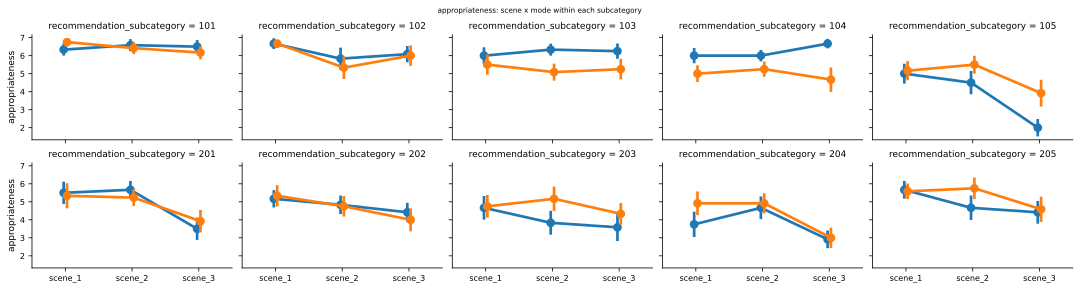

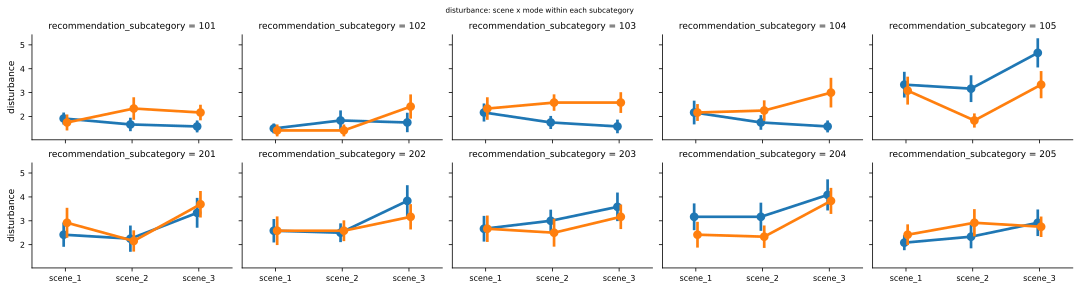

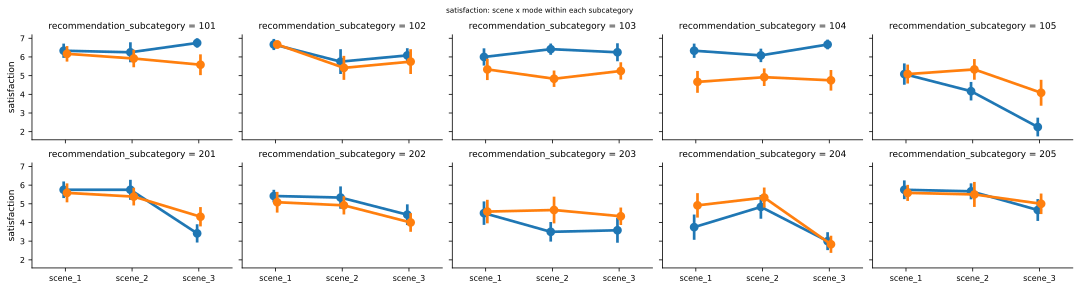

In [455]:
for metric in metrics:
    g = sns.catplot(
        data=df,
        x="scene_id",
        y=metric,
        hue="mode",
        col="recommendation_subcategory",
        kind="point",
        errorbar="se",
        dodge=True,
        col_wrap=5,
        height=2,
        aspect=1.5,
        legend=False,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"{metric}: scene x mode within each subcategory")
    for ax in g.axes.flat:
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

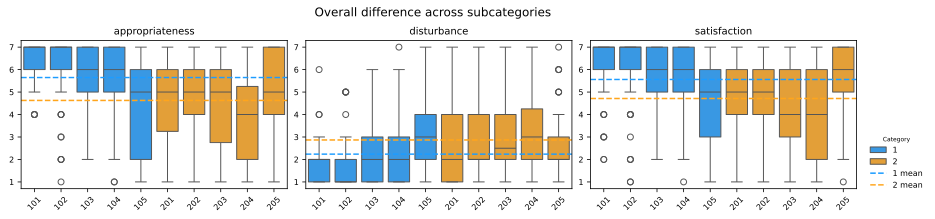

In [456]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=df,
        x="recommendation_subcategory",
        y=metric,
        hue="recommendation_category",
        palette=type_palette,
        ax=ax
    )

    # ===== type-level mean =====
    type_means = df.groupby("recommendation_category")[metric].mean()

    for t, mean_val in type_means.items():
        ax.axhline(
            y=mean_val,
            linestyle="--",
            linewidth=1.5,
            color=type_palette.get(t, "gray"),
            alpha=1.0,
            label=f"{t} mean"
        )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

fig.suptitle("Overall difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(
    handles, labels,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.0, 0.1),
    frameon=False
)

plt.show()

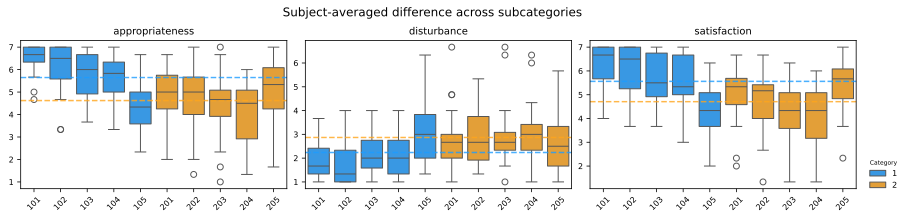

In [457]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

    # type/category 的整体均值
    type_means = agg.groupby("category")[metric].mean()

    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=agg,
        x="recommendation_subcategory",
        y=metric,
        hue="category",
        palette=type_palette,
        ax=ax
    )

    # 画不同 type 的均值横线
    for cat, mean_val in type_means.items():
        ax.axhline(
            y=mean_val,
            color=type_palette.get(cat, "gray"),
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
        )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

fig.suptitle("Subject-averaged difference across subcategories", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(
    handles,
    labels,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.0, 0.1),
    frameon=False
)

plt.show()

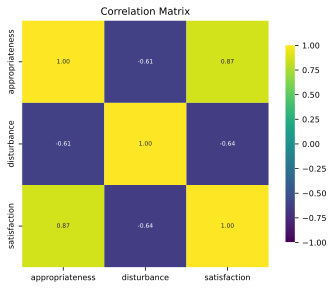

In [458]:
df_reaction[["appropriateness", "disturbance", "satisfaction"]].corr()

import seaborn as sns
import matplotlib.pyplot as plt

cols = ["appropriateness", "disturbance", "satisfaction"]
corr = df_reaction[cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

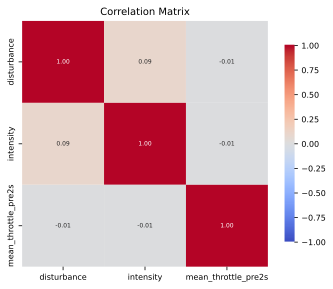

In [459]:
df_reaction[["disturbance", "intensity", "mean_throttle_pre2s"]].corr()

import seaborn as sns
import matplotlib.pyplot as plt

cols = ["disturbance", "intensity", "mean_throttle_pre2s"]
corr = df_reaction[cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Phase II

In [460]:
phase_II = "phaseII"
sub_nums_II = [3,5,7,8,11,16,19,20,22,]
# sub_nums_II = [3,4,5,7,8,9,11,16,19,20,22,24]

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir_II = DATA_DIR / phase_II

df_subcategory_rating_II = pd.read_csv(data_dir_II / "Rating_subcategory.csv")
df_subcategory_rating_II = readsubcategoryrating.format(df_subcategory_rating_II)

In [461]:
print(df_subcategory_rating_II['version'].unique())

['Personalized' 'Personified']


In [462]:
data_dict_II = defaultdict(dict)

for sub in sub_nums_II:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir_II.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 2, f"sub {sub} has more than 2 folders"

    for j, sub_dir in enumerate(sub_dirs):
        scene_key = "scene_4" if (sub %2 == 1 and j % 2 == 0) or (sub %2 == 0 and j % 2 == 1) else "scene_5"
        version = "personalized" if (sub %2, j % 2) == (1,0) or (sub %2, j % 2) == (0,1) else "personified"

        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating_II[(df_subcategory_rating_II["sub_id"] == sub) & (df_subcategory_rating_II["version"].str.lower() == version)]
        if sub_rating.empty:
            print(f"Warning: no subcategory rating found for sub {sub}, version {version}")
            sub_rating = None

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        data_dict_II[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

df_trial_II = build_trial_level_df(data_dict_II)
print(f"Number of trials for each version:")
for sub in sub_nums_II:
    for version in ["personalized", "personified"]:
        count = df_trial_II[
            (df_trial_II["sub"] == sub) &
            (df_trial_II["version"] == version)
        ].shape[0]
        print(f"Sub {sub}, Version {version}: {count} trials")

assert df_trial_II[df_trial_II['version']=='personalized'].shape[0] == df_trial_II[df_trial_II['version']=='personified'].shape[0], "Version counts do not match"

df_trial_baseline = df_trial[
    (df_trial['sub'].isin(sub_nums_II)) &
    (df_trial['scene'] == 'scene_3')
]

df_trial_merge_II = pd.concat([df_trial_baseline, df_trial_II], ignore_index=True)

Number of trials for each version:
Sub 3, Version personalized: 10 trials
Sub 3, Version personified: 10 trials
Sub 5, Version personalized: 10 trials
Sub 5, Version personified: 10 trials
Sub 7, Version personalized: 10 trials
Sub 7, Version personified: 10 trials
Sub 8, Version personalized: 10 trials
Sub 8, Version personified: 10 trials
Sub 11, Version personalized: 10 trials
Sub 11, Version personified: 10 trials
Sub 16, Version personalized: 10 trials
Sub 16, Version personified: 10 trials
Sub 19, Version personalized: 10 trials
Sub 19, Version personified: 10 trials
Sub 20, Version personalized: 10 trials
Sub 20, Version personified: 10 trials
Sub 22, Version personalized: 10 trials
Sub 22, Version personified: 10 trials


In [463]:
print(df_trial_II['version'].unique())

['personalized' 'personified']


In [464]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ version * type * driving",
    df_trial_merge_II,
    groups=df_trial_merge_II["sub"]
)

result = model.fit()
print(result.summary())

def test_effect(result, terms):
    print("\nTesting:", terms)
    print(result.wald_test(terms))

# main effects
test_effect(result, "version[T.personified] = 0")
test_effect(result, "version[T.personalized] = 0")
test_effect(result, "type = 0")
# test_effect(result, "C(type, Sum)[S.1] = 0")

                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            accept   
No. Observations:             270                Method:                        REML     
No. Groups:                   9                  Scale:                         0.1834   
Min. group size:              30                 Log-Likelihood:                -167.6830
Max. group size:              30                 Converged:                     Yes      
Mean group size:              30.0                                                       
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                       1.100    0.216  5.082 0.000  0.676  1.524
version[T.personalized]             

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [465]:
for t in [1, 2]:
    df_sub = df_trial_merge_II[df_trial_merge_II["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ version * driving",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())

    # # ===== main effects =====
    # print("\n-- Main Effects --")
    
    # # driving
    # print("\nDriving effect:")
    # print(result.wald_test("C(driving, Sum)[S.auto] = 0"))
    
    # # scene（joint test）
    # print("\nScene effect:")
    # print(result.wald_test("""
    #     C(scene, Sum)[S.scene_1] = 0,
    #     C(scene, Sum)[S.scene_2] = 0
    # """))
    
    # # ===== interaction =====
    # print("\n-- Interaction --")
    
    # print("\nDriving × Scene:")
    # print(result.wald_test("""
    #     C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_1] = 0,
    #     C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_2] = 0
    # """))


=== Type 1 ===
                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           accept  
No. Observations:           135               Method:                       REML    
No. Groups:                 9                 Scale:                        0.2098  
Min. group size:            15                Log-Likelihood:               -91.6556
Max. group size:            15                Converged:                    Yes     
Mean group size:            15.0                                                    
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.700    0.102  6.834 0.000  0.499  0.901
version[T.personalized]                    0.150    0.145  1.035 0.300 -0

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter 

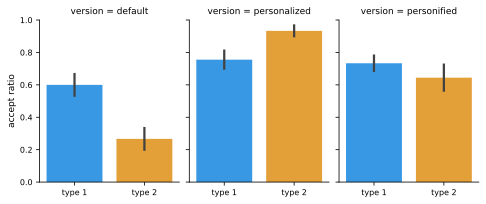

     scene driving  type  accept_mean  reject_mean  ignore_mean   n
0  scene_3    auto     1     0.783333     0.216667     0.000000  12
1  scene_3    auto     2     0.566667     0.416667     0.016667  12
2  scene_3  manual     1     0.626667     0.253333     0.120000  15
3  scene_3  manual     2     0.653333     0.253333     0.093333  15

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_3: type1(n=27, mean=0.696, median=0.800) | type2(n=27, mean=0.615, median=0.600) | U=396.000, p=0.5793

--- reject ---
scene_3: type1(n=27, mean=0.237, median=0.200) | type2(n=27, mean=0.326, median=0.200) | U=314.500, p=0.3728

--- ignore ---
scene_3: type1(n=27, mean=0.067, median=0.000) | type2(n=27, mean=0.059, median=0.000) | U=405.000, p=0.3657


In [466]:
df_stats_baseline = df_stats[(df_stats['sub'].isin(sub_nums_II)) & ((df_stats['scene'] == 'scene_3'))].copy()

df_stats_II = extract_reaction_stats(data_dict_II)

df_stats_merge_II = pd.concat([df_stats_baseline, df_stats_II], ignore_index=True)

plot_type_facet(df_stats_merge_II, col="version")

summary = summarize_scene(df_stats_merge_II)

test_scene_type_diff(df_stats_merge_II)

In [467]:
df_subcategory_rating_II['trial_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [468]:
df_reaction_II = databuilder.build_per_reaction_df(
    data_dict_II,
    intensity_dict = stimuli_intensity_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
    # df_subject_prior=df_subject_prior,
)

df_reaction_baseline = df_reaction[
    (df_reaction['sub_id'].isin(sub_nums_II)) &
    (df_reaction['scene_id'] == 'scene_3')
]

print(df_reaction_II.shape)
df_reaction_merged_II = pd.concat([df_reaction_baseline, df_reaction_II], ignore_index=True)
print(df_reaction_merged_II.shape)
df_reaction_all = pd.concat([df_reaction, df_reaction_II], ignore_index=True)
print(df_reaction_all.shape)

# reaction_data_dict_II = databuilder.build_per_reaction_data_dict(df_reaction_II)
print(df_reaction_merged_II.columns)

(180, 29)
(270, 29)
(902, 29)
Index(['sub_id', 'scene_id', 'mode', 'version', 'trial_id', 'recommendation',
       'recommendation_category', 'recommendation_subcategory',
       'subject_prior_accept_prob_subcategory', 'prior_mean_throttle_input',
       'prior_var_throttle_input', 'intensity', 'coherence',
       'mean_throttle_input_zscore_pre2s', 'mean_throttle_pre2s',
       'var_throttle_pre2s', 'car_density', 'time_pressure', 'reaction',
       'accept', 'reaction_time_ms', 'mean_throttle_input_zscore_post5s',
       'mean_throttle_post5s', 'var_throttle_post5s', 'appropriateness',
       'disturbance', 'satisfaction', 'reaction__time_ms', 'trigger__time_ms'],
      dtype='object')


In [469]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_rel, ttest_1samp, friedmanchisquare
from itertools import combinations


# =========================================================
# 0) 基础准备
# =========================================================
df = df_reaction_merged_II.copy()

if not isinstance(df["recommendation_subcategory"].dtype, pd.CategoricalDtype):
    df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")

subcat_levels = list(df["recommendation_subcategory"].cat.categories)


# =========================================================
# 1) 每个 subcategory 内部:
#    metric ~ version * mode
#    这里保留你原来的 mixed model
# =========================================================
per_subcat_results = []
per_subcat_models = {}

for subcat in subcat_levels:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ version * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Per-subcat model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)


# =========================================================
# 2) FDR by (metric, term)
# =========================================================
def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    if len(df_out) == 0:
        return df_out

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for _, idx in grouped.groups.items():
        idx = list(idx)
        pvals = df_out.loc[idx, p_col].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = np.array(idx)
            df_out.loc[idx_arr[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)


# =========================================================
# 3) 汇总 version / mode / interaction
# =========================================================
summary_rows = []

for subcat in subcat_levels:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        version_terms = df_tmp[
            df_tmp["term"].str.contains("version", regex=False, na=False) &
            ~df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        mode_terms = df_tmp[
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains("version", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("version", regex=False, na=False) &
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "version_min_p": version_terms["pval"].min() if len(version_terms) else np.nan,
            "version_min_p_fdr": version_terms["pval_fdr"].min() if len(version_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)


# =========================================================
# 4) category 内部：
#    用更适合当前设计的方法
#
#    A. overall subcategory effect within each category:
#       Friedman test
#
#    B. 每个 subcategory vs 所属 category 内均值:
#       先做 subject × subcategory 平均，
#       再做 one-sample t-test on:
#       subcategory_mean - subject_specific_category_mean
# =========================================================
category_subcat_effect_rows = []
category_factor_tests = []

for metric in metrics:
    for rec_cat in sorted(df["recommendation_category"].dropna().unique()):
        df_cat = df[df["recommendation_category"] == rec_cat].copy()

        # subject × subcategory 平均
        agg = (
            df_cat.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
            .mean()
            .reset_index()
        )

        wide = agg.pivot(
            index="sub_id",
            columns="recommendation_subcategory",
            values=metric
        )

        # 按列顺序保持 subcategory 排序
        cols_sorted = sorted(wide.columns.tolist())
        wide = wide.reindex(columns=cols_sorted)

        # -------------------------------------------------
        # 4A) 整体 subcategory effect within category
        # Friedman test 需要 complete cases
        # -------------------------------------------------
        wide_complete = wide.dropna()

        if wide_complete.shape[0] >= 2 and wide_complete.shape[1] >= 2:
            try:
                stat, pval = friedmanchisquare(
                    *[wide_complete[c].values for c in wide_complete.columns]
                )
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": stat,
                    "subcategory_overall_p": pval,
                    "subcategory_df": wide_complete.shape[1] - 1,
                    "n_subjects_overall": wide_complete.shape[0],
                })
            except Exception as e:
                print(f"Friedman failed for metric={metric}, category={rec_cat}: {e}")
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": np.nan,
                    "subcategory_overall_p": np.nan,
                    "subcategory_df": np.nan,
                    "n_subjects_overall": wide_complete.shape[0],
                })
        else:
            category_factor_tests.append({
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcategory_overall_chi2": np.nan,
                "subcategory_overall_p": np.nan,
                "subcategory_df": np.nan,
                "n_subjects_overall": wide_complete.shape[0],
            })

        # -------------------------------------------------
        # 4B) 每个 subcategory vs category mean
        #
        # 对每个被试:
        # diff_subcat = subcat_mean - subject_category_mean
        #
        # 然后对 diff_subcat 做 one-sample t-test vs 0
        # -------------------------------------------------
        subj_cat_mean = wide.mean(axis=1)

        for subcat in wide.columns:
            diff = (wide[subcat] - subj_cat_mean).dropna()

            if len(diff) >= 2:
                stat, pval = ttest_1samp(diff, popmean=0.0, nan_policy="omit")
                coef = diff.mean()
                n_subjects = len(diff)
            else:
                stat, pval, coef, n_subjects = np.nan, np.nan, np.nan, len(diff)

            category_subcat_effect_rows.append({
                "subcategory": subcat,
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcat_coef": coef,
                "subcat_p": pval,
                "subcat_t": stat,
                "n_subjects": n_subjects
            })

category_subcat_effect_df = pd.DataFrame(
    category_subcat_effect_rows,
    columns=[
        "subcategory",
        "metric",
        "recommendation_category",
        "subcat_coef",
        "subcat_p",
        "subcat_t",
        "n_subjects"
    ]
)

category_factor_tests_df = pd.DataFrame(
    category_factor_tests,
    columns=[
        "metric",
        "recommendation_category",
        "subcategory_overall_chi2",
        "subcategory_overall_p",
        "subcategory_df",
        "n_subjects_overall"
    ]
)


# =========================================================
# 5) FDR for subcategory-vs-category-mean
#    在每个 (metric, recommendation_category) 内做 FDR
# =========================================================
category_subcat_effect_df["subcat_p_fdr"] = np.nan

if len(category_subcat_effect_df) > 0:
    for metric in metrics:
        for rec_cat in category_subcat_effect_df["recommendation_category"].dropna().unique():
            idx = (
                (category_subcat_effect_df["metric"] == metric) &
                (category_subcat_effect_df["recommendation_category"] == rec_cat)
            )
            pvals = category_subcat_effect_df.loc[idx, "subcat_p"].astype(float).values
            mask = ~np.isnan(pvals)

            if mask.sum() > 0:
                corrected = multipletests(pvals[mask], method="fdr_bh")[1]
                idx_arr = category_subcat_effect_df.index[idx].to_numpy()
                category_subcat_effect_df.loc[idx_arr[mask], "subcat_p_fdr"] = corrected


# =========================================================
# 6) merge
# =========================================================
summary_df = summary_df.merge(
    df[["recommendation_subcategory", "recommendation_category"]]
    .drop_duplicates()
    .rename(columns={"recommendation_subcategory": "subcategory"}),
    on="subcategory",
    how="left"
)

summary_df = summary_df.merge(
    category_subcat_effect_df[
        [
            "subcategory",
            "metric",
            "recommendation_category",
            "subcat_coef",
            "subcat_p",
            "subcat_p_fdr",
            "subcat_t",
            "n_subjects"
        ]
    ],
    on=["subcategory", "metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.merge(
    category_factor_tests_df,
    on=["metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.sort_values(
    ["metric", "recommendation_category", "subcategory"]
).reset_index(drop=True)


# =========================================================
# 7) significance flags
# =========================================================
alpha = 0.05
summary_df["version_sig"] = summary_df["version_min_p_fdr"] < alpha
summary_df["mode_sig"] = summary_df["mode_min_p_fdr"] < alpha
summary_df["interaction_sig"] = summary_df["interaction_min_p_fdr"] < alpha
summary_df["subcat_vs_category_mean_sig"] = summary_df["subcat_p_fdr"] < alpha
summary_df["subcategory_overall_sig"] = summary_df["subcategory_overall_p"] < alpha


# =========================================================
# 8) 输出
# =========================================================
summary_df

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.wa

,subcategory,metric,version_min_p,version_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr,recommendation_category,subcat_coef,...,n_subjects,subcategory_overall_chi2,subcategory_overall_p,subcategory_df,n_subjects_overall,version_sig,mode_sig,interaction_sig,subcat_vs_category_mean_sig,subcategory_overall_sig
0,101,appropriateness,1.000000e+00,1.000000e+00,0.220670,0.301230,0.009375,0.046875,1,1.014815,...,9,15.861111,0.003211,4,9,False,False,True,True,True
1,102,appropriateness,6.391393e-01,9.130562e-01,0.095303,0.301230,0.021072,0.070239,1,0.755556,...,9,15.861111,0.003211,4,9,False,False,False,False,True
2,103,appropriateness,3.091087e-01,8.083441e-01,0.240984,0.301230,0.288537,0.486032,1,0.459259,...,9,15.861111,0.003211,4,9,False,False,False,False,True
3,104,appropriateness,7.696274e-01,9.192104e-01,0.002062,0.020621,0.149672,0.374179,1,0.162963,...,9,15.861111,0.003211,4,9,False,True,False,False,True
4,105,appropriateness,1.266974e-01,2.111623e-01,0.034359,0.171797,0.379859,0.772955,1,-2.392593,...,9,15.861111,0.003211,4,9,False,False,False,True,True
5,201,appropriateness,3.740913e-09,3.740913e-08,0.159958,0.301230,0.291619,0.486032,2,0.281481,...,9,8.166667,0.085660,4,9,True,False,False,False,False
6,202,appropriateness,3.033101e-05,1.405743e-04,0.144658,0.301230,0.009016,0.046875,2,0.022222,...,9,8.166667,0.085660,4,9,True,False,True,False,False
7,203,appropriateness,4.519195e-02,9.038389e-02,0.888356,0.921980,0.273624,0.772955,2,0.429630,...,9,8.166667,0.085660,4,9,False,False,False,False,False
8,204,appropriateness,3.404170e-02,8.510425e-02,0.921980,0.921980,0.439898,0.628425,2,-0.977778,...,9,8.166667,0.085660,4,9,False,False,False,True,False
9,205,appropriateness,4.217229e-05,1.405743e-04,0.201357,0.301230,0.009096,0.090959,2,0.244444,...,9,8.166667,0.085660,4,9,True,False,False,False,False


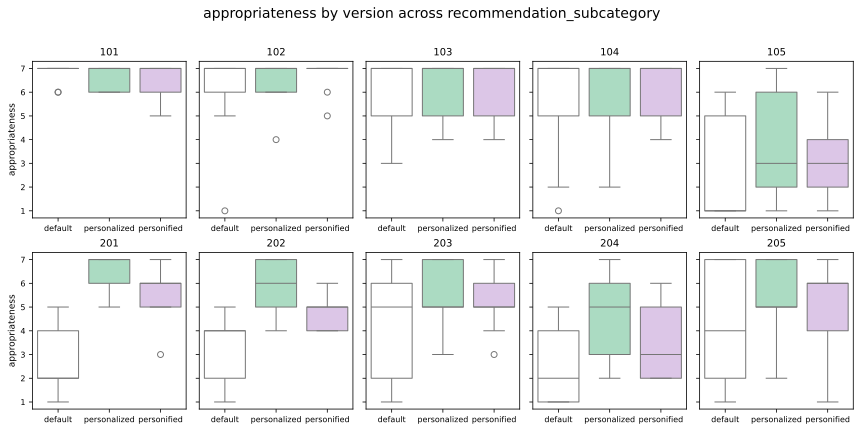

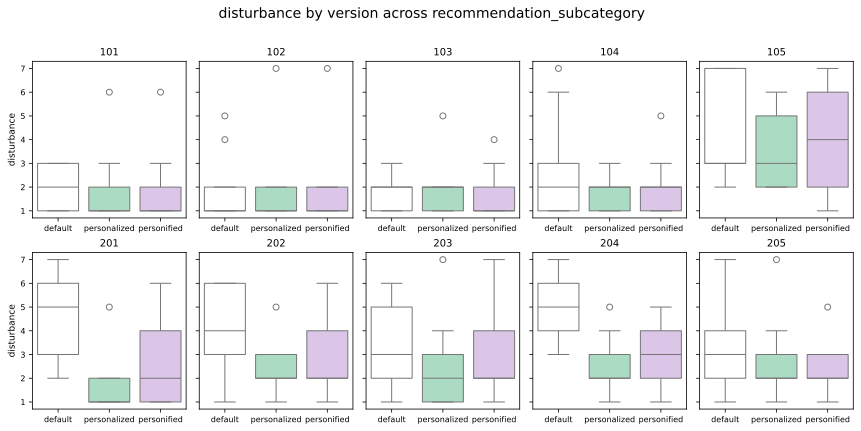

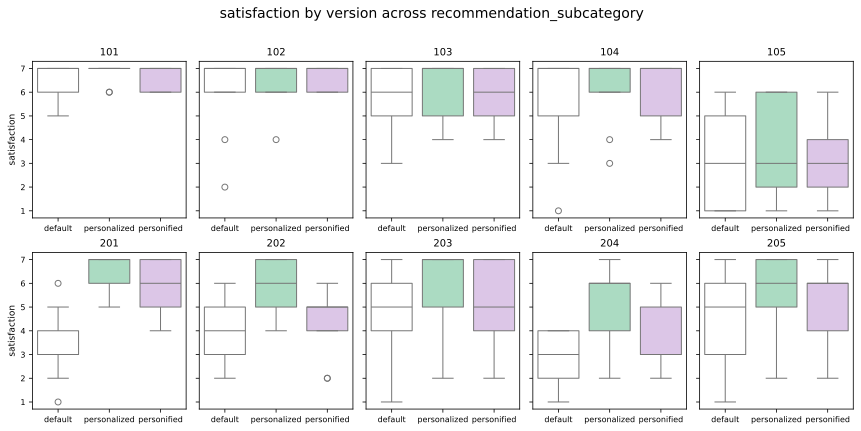

In [470]:
for metric in metrics:

    plotter.plot_metric_by_group_across_subcategories(
        df_reaction_merged_II,
        figsize_per_ax=(2.4,3),
        metric=metric,
        group="version",
        style="boxplot",
        rotate_xticks=0,
    )

In [471]:
merge_keys = ["sub_id", "mode", "scene_id", "recommendation_subcategory"]

df_reaction_diff = df_reaction_II.copy()

for metric in metrics:
    df_reaction_diff = df_reaction_diff.merge(
        df_reaction[merge_keys + [metric]].rename(columns={metric: f"{metric}_base"}),
        on=merge_keys,
        how="left"
    )
    
    df_reaction_diff[f"{metric}_diff"] = (
        df_reaction_diff[metric] - df_reaction_diff[f"{metric}_base"]
    )

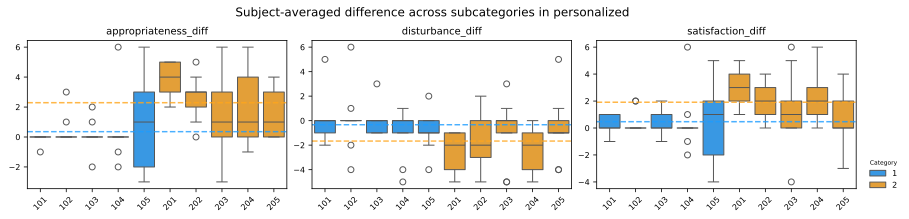

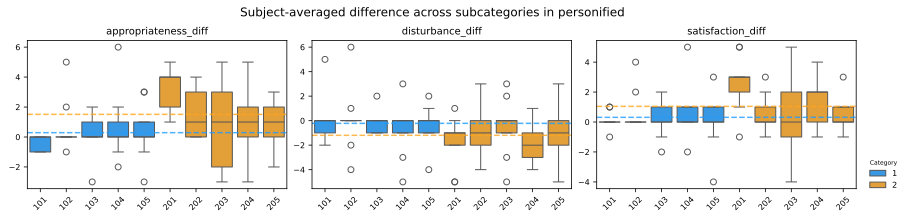

In [472]:
metrics_diff = [f"{m}_diff" for m in metrics]

for version in df_reaction_diff["version"].dropna().unique():
    df = df_reaction_diff[df_reaction_diff["version"] == version]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))


    for i, metric in enumerate(metrics_diff):
        agg = (
            df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
            .mean()
            .reset_index()
        )

        agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

        # type/category
        type_means = agg.groupby("category")[metric].mean()

        ax = axes[i] if len(metrics_diff) > 1 else axes

        sns.boxplot(
            data=agg,
            x="recommendation_subcategory",
            y=metric,
            hue="category",
            palette=type_palette,
            ax=ax
        )

        # type mean lines
        for cat, mean_val in type_means.items():
            ax.axhline(
                y=mean_val,
                color=type_palette.get(cat, "gray"),
                linestyle="--",
                linewidth=1.5,
                alpha=0.8,
            )

        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("")
        ax.set_ylabel("")

        if ax.get_legend() is not None:
            handles, labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    fig.suptitle(f"Subject-averaged difference across subcategories in {version}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 1])

    fig.legend(
        handles,
        labels,
        title="Category",
        loc="lower left",
        bbox_to_anchor=(1.0, 0.1),
        frameon=False
    )

    plt.show()

## 4.2 Baseline Model: logistic regression and svm

In [473]:
features = [
    "subject_prior_accept_prob_subcategory",
    "intensity",
    "coherence",
    "var_throttle_pre2s",
    "mean_throttle_pre2s",
    "car_density",
    "time_pressure",
    "mode",
    # "appropriateness",
    # "disturbance",
    # "satisfaction",
]

target = "accept"

In [474]:
print("==============================================")
print("logistic regression:")
print("==============================================")

res_logistic = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="logistic",
    n_splits=5,
    class_weight="balanced"
)

print("==============================================")
print("svm:")
print("==============================================")

res_svm = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="svm",
    n_splits=5,
    class_weight="balanced"
)

print("==============================================")
print("mlp:")
print("==============================================")
res_mlp = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="mlp",
    n_splits=5,
    hidden_layer_sizes=(32, 8)
)

logistic regression:
Accuracy per fold: [0.64640884 0.74033149 0.7        0.69444444 0.63888889]
AUC per fold: [0.68278571 0.75842857 0.74265553 0.71860599 0.69261233]
Mean Accuracy: 0.6840 ± 0.0374
Mean AUC: 0.7190 ± 0.0287

Overall CV Accuracy: 0.6840354767184036
Overall CV AUC: 0.7175872760679836

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.62      0.55       280
           1       0.81      0.71      0.76       622

    accuracy                           0.68       902
   macro avg       0.65      0.67      0.65       902
weighted avg       0.71      0.68      0.69       902


Feature importance (mean ± std):
                                 feature  coef_mean  coef_std  abs_mean  \
0  subject_prior_accept_prob_subcategory   0.779221  0.043861  0.779221   
2                              coherence   0.460432  0.025804  0.460432   
6                          time_pressure  -0.238135  0.053203  0.238135   
4             

## 4.3 1d Dynamics Simulation

The latent decision state `x` evolves as:

`change in x = leak + nonlinear term + input drive + noise`

More specifically:

`dx/dt = -lam * x + a * tanh(gain * (x - theta_dyn)) + u + noise`

where:

- `lam`: how strongly the state decays back
- `a`: strength of nonlinear attraction
- `gain`: steepness of the nonlinearity
- `theta_dyn`: center of the nonlinear curve
- `u`: evidence / pressure input
- `noise`: random fluctuation

Initial state:

`x0 = kappa * logit(p0)`

Decision readout:

`p_accept = sigmoid(x_final - theta_readout)`

Important:

- `theta_dyn` is part of the dynamics
- `theta_readout` is the final decision threshold
- nullcline means `dx/dt = 0`

In [475]:
dummy_row = pd.Series({

    # ---------------- meta ----------------
    "sub_id": 0,
    "scene_id": "scene_1",
    "mode": "manual",
    "trial_id": 0,
    "recommendation": "dummy recommendation",
    "recommendation_category": 1,
    "recommendation_subcategory": 101,

    # ---------------- prior ----------------
    "subject_prior_accept_prob_subcategory": 0.5,
    "prior_mean_throttle_input": 0.0,
    "prior_var_throttle_input": 0.0,

    # ---------------- scenario ----------------
    "intensity": 0.0,
    "coherence": 1.0,
    "mean_throttle_input_zscore_pre2s": 0.0,
    "mean_throttle_pre2s": 0.0,
    "var_throttle_pre2s": 0.0,
    "car_density": 0.0,
    "time_pressure": 0,

    # ---------------- reaction ----------------
    "reaction": "ignore",
    "accept": False,
    "reaction_time_ms": np.nan,
    "mean_throttle_input_zscore_post5s": 0.0,
    "mean_throttle_post5s": 0.0,
    "var_throttle_post5s": 0.0,

    # ---------------- evaluation ----------------
    "appropriateness": 0.0,
    "disturbance": 0.0,
    "satisfaction": 0.0,

    # ---------------- bookkeeping ----------------
    "reaction__time_ms": 0.0,
    "trigger__time_ms": 0.0,
})

scene_id :scene_1, mode: manual, subcatgory: 101
===== Single Trial Demo (1D) =====
model = nonlinear_sigmoid
prior p0 = 0.500
x0 = -0.089
u = 0.950
lam_eff = 1.000
sigma_eff = 0.040
gain_eff = 2.500
theta_dyn = 0.000
theta_readout = 0.000
x_final = 3.326
p_accept = 0.965
predicted accept = 1
fixed points:
  x* = -1.369, stable, slope=-0.617
  x* = -0.575, unstable, slope=0.939
  x* = 3.424, stable, slope=-0.998


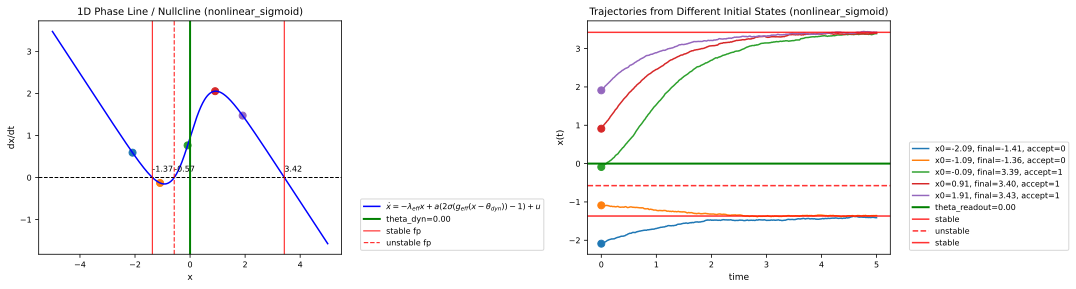

In [476]:
# row = df_reaction.iloc[100]
# beta_c = 0.3394
#   beta_i = 0.5997
#   beta_ci = 0.8067
#   gamma_throttle = 1.2526
#   gamma_density = 0.9690
#   gamma_time = 0.1459
#   gamma_mode = 0.9449
#   kappa = 1.0156
#   lam = 0.1712
#   a = 0.4175
#   gain = 0.7931
row = dummy_row
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

result = oneddynamics.run_single_trial_demo(
    row,
    model="nonlinear_sigmoid",
    beta_c=1.0,
    beta_i=2.0,
    beta_ci=0.5,

    gamma_throttle=0.3,
    gamma_density=0.05,
    gamma_time=0.3,
    gamma_mode=0.05,

    kappa=1.0,
    lam=1.0,
    a=2.5,
    gain=2.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

In [477]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_reaction_all, groups=df_reaction_all["sub_id"]))

train_df = df_reaction_all.iloc[train_idx].copy()
test_df  = df_reaction_all.iloc[test_idx].copy()

In [478]:
fixed_params = dict(
    model="nonlinear_sigmoid",
    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

param_names = [
    "beta_c",
    "beta_i",
    "beta_ci",
    "gamma_throttle",
    "gamma_density",
    "gamma_time",
    "gamma_mode",
    "kappa",
    "lam",
    "a",
    "gain",
]

bounds = [
    (0.0, 5.0),   # beta_c
    (0.0, 5.0),   # beta_i
    (0.0, 5.0),   # beta_ci
    (0.0, 3.0),   # gamma_throttle
    (0.0, 3.0),   # gamma_density
    (0.0, 3.0),   # gamma_time
    (0.0, 3.0),   # gamma_mode
    (0.1, 5.0),    # kappa
    (0.1, 5.0),    # lam
    (0.1, 8.0),    # a
    (0.1, 8.0),    # gain
]

In [479]:
b_optimize = False

def objective(vec):
    loss = optim.objective(
        train_df,
        vec,
        oneddynamics.simulate_dataframe_decisions,
        fixed_params=fixed_params,
        param_names=param_names,
    )

    reg_lambda = 0.01
    reg = reg_lambda * np.sum(vec**2)

    return loss + reg

if b_optimize: 

    early_stopper = optim.EarlyStopper(
        patience=5,
        min_delta=1e-3,
        objective=objective,
    )

    result_de = differential_evolution(
        objective,
        bounds=bounds,
        strategy="best1bin",
        maxiter=100,
        popsize=10,
        tol=1e-3,
        mutation=(0.5, 1.0),
        recombination=0.7,
        polish=False,
        disp=True,
        workers=1,
        seed=42,
        callback=early_stopper,
    )

    print("DE total objective:", result_de.fun)
    print("DE best params:")
    best_params = {}
    for k, v in zip(param_names, result_de.x):
        best_params[k] = float(v)
        print(f"  {k} = {v:.4f}")


    result_local = minimize(
        objective,
        x0=result_de.x,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 100,
            "ftol": 1e-4,
            "gtol": 1e-4,
        },
    )

    print("\nLocal total objective:", result_local.fun)
    print("Local best params:")
    best_params = {}
    for k, v in zip(param_names, result_local.x):
        best_params[k] = float(v)
        print(f"  {k} = {v:.4f}")

In [480]:
# 0  subject_prior_accept_prob_subcategory   0.779221  0.043861  0.779221   
# 2                              coherence   0.460432  0.025804  0.460432   
# 6                          time_pressure  -0.238135  0.053203  0.238135   
# 4                    mean_throttle_pre2s  -0.157415  0.143995  0.157415   
# 3                     var_throttle_pre2s   0.133403  0.238511  0.133403   
# 1                              intensity  -0.099898  0.038354  0.099898   
# 5                            car_density  -0.079351  0.025464  0.079351   
# 7                                   mode   0.004698  0.018033  0.004698  

manual_params = {
    "model": "nonlinear_sigmoid",
    "beta_c": 2.0,
    "beta_i": 1.0,
    "beta_ci": 0.25,
    
    "gamma_throttle": 0.15,
    "gamma_density": 0.08,
    "gamma_time": 0.25,
    "gamma_mode": 0.005,

    "kappa": 1.5,
    "lam": 1.0,
    "a": 2.5,
    "gain": 1.5,
    "theta_dyn": 0.0,

    "sigma": 0.04,
    "theta_readout": 0.0,
    "dt": 0.01,
    "T": 5.0,
    
    "density_lam_gain": 0.0,
    "density_sigma_gain": 0.0,
    "time_gain_multiplier": 1.0,
    "auto_lam_multiplier": 1.0,
    "auto_sigma_multiplier": 1.0,
}


In [481]:
# final_params = dict(fixed_params)
# final_params.update(best_params)

df_sim_test = oneddynamics.simulate_dataframe_decisions(
    test_df,
    **manual_params
)

valid = df_sim_test.dropna(subset=["accept_true", "p_accept_pred"]).copy()
y_true = valid["accept_true"].astype(int).values
y_prob = np.clip(valid["p_accept_pred"].astype(float).values, 1e-6, 1 - 1e-6)
y_pred = (y_prob >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Test AUC:", roc_auc_score(y_true, y_prob))
print("Test LogLoss:", log_loss(y_true, y_prob))

final_loss = optim.objective(
    train_df,
    result_de.x,
    oneddynamics.simulate_dataframe_decisions,
    fixed_params=fixed_params,
    param_names=param_names,
)
reg = 0.01 * np.sum(result_de.x**2)

print("DE objective (no reg):", final_loss)
print("DE reg:", reg)
print("DE total objective:", result_de.fun)
print("DE accuracy approx:", -final_loss)

Test Accuracy: 0.7588235294117647
Test AUC: 0.7028411737307871
Test LogLoss: 0.6368382528957793
DE objective (no reg): -0.6980874316939891
DE reg: 0.06411768862459356
DE total objective: -0.6326036228508163
DE accuracy approx: 0.6980874316939891


In [482]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_sim_test["accept_true"], df_sim_test["accept_pred"])
print(cm)

[[30 27]
 [14 99]]


In [483]:
corr_df = oneddynamics.build_dynamical_correction_features(df_reaction_all)
df_model = df_reaction_all.join(corr_df.set_index("idx"), how="left")

In [484]:
df_model[["xT_nonlinear", "accept"]].corr()

,xT_nonlinear,accept
xT_nonlinear,1.000000,0.311591
accept,0.311591,1.000000


In [485]:
X_base = df_model[features]
y = df_model["accept"].astype(int)

dynamics_feature = features + ["delta_nonlinear_extra",]
X_corr = df_model[dynamics_feature]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = X_corr
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

coef = pipe.named_steps["clf"].coef_[0]
feature_importance = pd.Series(coef, index=dynamics_feature).sort_values()

print(feature_importance)

Accuracy: 0.6961325966850829
AUC: 0.6991428571428572
              precision    recall  f1-score   support

           0       0.51      0.38      0.43        56
           1       0.75      0.84      0.79       125

    accuracy                           0.70       181
   macro avg       0.63      0.61      0.61       181
weighted avg       0.68      0.70      0.68       181

time_pressure                           -0.189779
mean_throttle_pre2s                     -0.148321
intensity                               -0.063296
car_density                             -0.056120
var_throttle_pre2s                      -0.051674
mode                                    -0.017580
delta_nonlinear_extra                    0.014103
coherence                                0.516774
subject_prior_accept_prob_subcategory    0.836418
dtype: float64


In [486]:
# df_type_two = df_reaction[df_reaction["recommendation_category"] == 2]

# time_pressure                           -0.190380
# mean_throttle_pre2s                     -0.146696
# intensity                               -0.062081
# car_density                             -0.056921
# var_throttle_pre2s                      -0.051733
# mode                                    -0.018109
# coherence                                0.522983
# subject_prior_accept_prob_subcategory    0.848404

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# =========================
# config
# =========================
n_splits = 5
groups = df_reaction_all["sub_id"]

sim_params = dict(
    model="nonlinear_sigmoid",
    beta_c=1.0,
    beta_i=2.0,
    beta_ci=0.5,

    gamma_throttle=0.3,
    gamma_density=0.05,
    gamma_time=0.3,
    gamma_mode=0.05,

    kappa=1.0,
    lam=1.0,
    a=2.5,
    gain=2.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

# =========================
# CV
# =========================
gkf = GroupKFold(n_splits=n_splits)

rows = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df_reaction_all, groups=groups), start=1
):
    train_df = df_reaction_all.iloc[train_idx].copy()
    test_df  = df_reaction_all.iloc[test_idx].copy()

    df_sim_test = oneddynamics.simulate_dataframe_decisions(
        test_df,
        **sim_params
    )

    valid = df_sim_test.dropna(subset=["accept_true", "accept_pred"]).copy()

    if len(valid) == 0:
        acc = np.nan
        auc = np.nan
        nll = np.nan
        accept_rate = np.nan
    else:
        y_true = valid["accept_true"].astype(int).values
        y_prob = np.clip(valid["accept_pred"].astype(float).values, 1e-6, 1 - 1e-6)
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_true, y_pred)

        if len(np.unique(y_true)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)

        nll = log_loss(y_true, y_prob)
        accept_rate = y_true.mean()

    rows.append({
        "fold": fold,
        "n_valid": len(valid),
        "accept_rate": accept_rate,
        "acc": acc,
        "auc": auc,
        "logloss": nll,
    })

    print(f"Fold {fold}:")
    print(f"  n_valid = {len(valid)}")
    print(f"  original acceptance rate = {accept_rate:.4f}" if pd.notna(accept_rate) else "  original acceptance rate = nan")
    print(f"  accuracy = {acc:.4f}" if pd.notna(acc) else "  accuracy = nan")
    print(f"  auc = {auc:.4f}" if pd.notna(auc) else "  auc = nan")
    print(f"  logloss = {nll:.4f}" if pd.notna(nll) else "  logloss = nan")
    print()

# =========================
# summary
# =========================
cv_results = pd.DataFrame(rows)

print("===== Overall CV Results =====")
print(f"ACC     mean = {cv_results['acc'].mean():.4f}, std = {cv_results['acc'].std(ddof=1):.4f}")
print(f"AUC     mean = {cv_results['auc'].mean():.4f}, std = {cv_results['auc'].std(ddof=1):.4f}")
print(f"LogLoss mean = {cv_results['logloss'].mean():.4f}, std = {cv_results['logloss'].std(ddof=1):.4f}")

display(cv_results)

Fold 1:
  n_valid = 190
  original acceptance rate = 0.7211
  accuracy = 0.7632
  auc = 0.6102
  logloss = 3.2721

Fold 2:
  n_valid = 190
  original acceptance rate = 0.6842
  accuracy = 0.6842
  auc = 0.5314
  logloss = 4.3628

Fold 3:
  n_valid = 190
  original acceptance rate = 0.7105
  accuracy = 0.7789
  auc = 0.6559
  logloss = 3.0540

Fold 4:
  n_valid = 160
  original acceptance rate = 0.6312
  accuracy = 0.7063
  auc = 0.6651
  logloss = 4.0583

Fold 5:
  n_valid = 172
  original acceptance rate = 0.6919
  accuracy = 0.7326
  auc = 0.6131
  logloss = 3.6948

===== Overall CV Results =====
ACC     mean = 0.7330, std = 0.0391
AUC     mean = 0.6151, std = 0.0529
LogLoss mean = 3.6884, std = 0.5403


,fold,n_valid,accept_rate,acc,auc,logloss
0,1,190,0.721053,0.763158,0.610178,3.272095
1,2,190,0.684211,0.684211,0.531410,4.362793
2,3,190,0.710526,0.778947,0.655892,3.053956
3,4,160,0.631250,0.706250,0.665128,4.058307
4,5,172,0.691860,0.732558,0.613128,3.694847


## 4.4 2d dynamics

The latent decision states \(x\) (accept) and \(y\) (reject) evolve as:

`change in state = leak + nonlinear term + input drive + noise`

---

### Dynamics

For accept state:

`dx/dt = -lam_x * x + phi_x(x + w_xy * y) + f_x + noise_x`

For reject state:

`dy/dt = -lam_y * y + phi_y(y + w_yx * x) + f_y + noise_y`

---

### Nonlinearity (Cubic)

`phi(z) = z - a * z^3`

- creates saturation and multi-stability  
- allows curved nullclines and attractor competition  

---

### Inputs (Drives)

Accept drive:

`f_x = alpha_prior * logit(p0)
     + alpha_coherence * coherence
     + alpha_intensity * intensity
     + alpha_ci * coherence * intensity
     + alpha_density * car_density`

Reject drive:

`f_y = beta_pressure * effective_pressure
     + beta_density * car_density
     + beta_time_pressure * time_pressure
     + beta_low_coherence * (1 - coherence)
     + beta_prior * (-logit(p0))`

---

### Context Modulation

`effective_pressure = pressure`

- reduced in auto mode via `auto_pressure_reduction`
- scaled by:
  - `density_pressure_gain`
  - `time_pressure_gain`

---

### Initial State

`x0 = kappa * logit(p0)`  
`y0 = -kappa * logit(p0)`

---

### Decision Readout

`decision = accept if (x_final - y_final) > theta`

or probabilistic:

`p_accept = sigmoid(x_final - y_final - theta)`

---

### Key Parameters

- `lam_x, lam_y`: decay (leak)
- `w_xy, w_yx`: cross-coupling (competition / excitation)
- `a`: cubic nonlinearity strength
- `sigma_x, sigma_y`: noise level
- `theta`: decision threshold

---

### Important

- competition is **implicit via coupling (w_xy, w_yx)**  
- nonlinearity shapes **attractor landscape**  
- prior enters both:
  - initial condition  
  - asymmetric drives (f_x vs f_y)  
- system outcome depends on **fixed points + trajectory**

---

### Nullcline

Nullcline is defined as:

`dx/dt = 0` and `dy/dt = 0`

Their intersection gives **fixed points** (decision attractors).


scene_id :scene_3, version: personalized, mode: 0, subcatgory: 202
===== Single Trial Demo (2D unified nonlinear) =====
prior_accept_prob = 0.600
coherence = 1.000
intensity = 0.369
stim_raw = 2.461
stim_on_x = 0.998
stim_on_y = 0.998
effective_pressure = 0.240
accept drive f_x = 2.461
reject drive f_y = 0.252
initial state = (0.118, -0.118)
fixed point = not found
final state = (0.666, -0.954)
final diff x-y = 1.620
p_accept = 0.835
accept_pred = 1


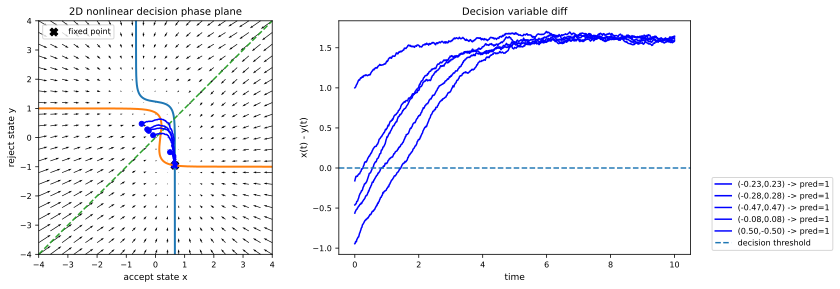

In [487]:
row = df_reaction_all.iloc[800]
# row = df_reaction_all.iloc[812]
# row = dummy_row
print(f"scene_id :{row['scene_id']}, version: {row['version']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

demo = twoddynamics.run_single_trial_demo_2d(
    row,
    auto_pressure_reduction=0.02,
    density_pressure_gain=0.05,
    time_pressure_gain=0.2,

    alpha_coherence=2.0,
    alpha_intensity=1.0,
    alpha_ci=0.25,

    beta_pressure=0.05,
    beta_density=0.05,
    beta_time_pressure=0.2,

    k_init=1.0,
    lam_x=1.5,
    lam_y=1.0,
    w_xy=2.0,
    w_yx=1.5,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,
    symmetric_gate=True,
)

In [488]:
# df_type_two = df_reaction[df_reaction["recommendation_category"] == 2]

# time_pressure                           -0.190380
# mean_throttle_pre2s                     -0.146696
# intensity                               -0.062081
# car_density                             -0.056921
# var_throttle_pre2s                      -0.051733
# mode                                    -0.018109
# coherence                                0.522983
# subject_prior_accept_prob_subcategory    0.848404

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# =========================
# config
# =========================
n_splits = 5
groups = df_reaction_all["sub_id"]

sim_params = dict(
    auto_pressure_reduction=0.02,
    density_pressure_gain=0.05,
    time_pressure_gain=0.2,

    alpha_coherence=2.0,
    alpha_intensity=1.0,
    alpha_ci=0.25,

    beta_pressure=0.05,
    beta_density=0.05,
    beta_time_pressure=0.2,

    k_init=1.0,
    lam_x=1.5,
    lam_y=1.0,
    w_xy=2.0,
    w_yx=1.5,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,
    symmetric_gate=True,
)

# =========================
# CV
# =========================
gkf = GroupKFold(n_splits=n_splits)

rows = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df_reaction_all, groups=groups), start=1
):
    train_df = df_reaction_all.iloc[train_idx].copy()
    test_df  = df_reaction_all.iloc[test_idx].copy()

    df_sim_test = twoddynamics.simulate_dataframe_2d(
        test_df,
        **sim_params
    )

    valid = df_sim_test.dropna(subset=["accept_true", "accept_pred"]).copy()

    if len(valid) == 0:
        acc = np.nan
        auc = np.nan
        nll = np.nan
        accept_rate = np.nan
    else:
        y_true = valid["accept_true"].astype(int).values
        y_prob = np.clip(valid["accept_pred"].astype(float).values, 1e-6, 1 - 1e-6)
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_true, y_pred)

        if len(np.unique(y_true)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)

        nll = log_loss(y_true, y_prob)
        accept_rate = y_true.mean()

    rows.append({
        "fold": fold,
        "n_valid": len(valid),
        "accept_rate": accept_rate,
        "acc": acc,
        "auc": auc,
        "logloss": nll,
    })

    print(f"Fold {fold}:")
    print(f"  n_valid = {len(valid)}")
    print(f"  original acceptance rate = {accept_rate:.4f}" if pd.notna(accept_rate) else "  original acceptance rate = nan")
    print(f"  accuracy = {acc:.4f}" if pd.notna(acc) else "  accuracy = nan")
    print(f"  auc = {auc:.4f}" if pd.notna(auc) else "  auc = nan")
    print(f"  logloss = {nll:.4f}" if pd.notna(nll) else "  logloss = nan")
    print()

# =========================
# summary
# =========================
cv_results = pd.DataFrame(rows)

print("===== Overall CV Results =====")
print(f"ACC     mean = {cv_results['acc'].mean():.4f}, std = {cv_results['acc'].std(ddof=1):.4f}")
print(f"AUC     mean = {cv_results['auc'].mean():.4f}, std = {cv_results['auc'].std(ddof=1):.4f}")
print(f"LogLoss mean = {cv_results['logloss'].mean():.4f}, std = {cv_results['logloss'].std(ddof=1):.4f}")

display(cv_results)

Fold 1:
  n_valid = 190
  original acceptance rate = 0.7211
  accuracy = 0.7632
  auc = 0.6160
  logloss = 3.2721

Fold 2:
  n_valid = 190
  original acceptance rate = 0.6842
  accuracy = 0.7053
  auc = 0.5737
  logloss = 4.0719

Fold 3:
  n_valid = 190
  original acceptance rate = 0.7105
  accuracy = 0.7684
  auc = 0.6539
  logloss = 3.1994

Fold 4:
  n_valid = 160
  original acceptance rate = 0.6312
  accuracy = 0.7188
  auc = 0.6856
  logloss = 3.8856

Fold 5:
  n_valid = 172
  original acceptance rate = 0.6919
  accuracy = 0.7442
  auc = 0.6425
  logloss = 3.5342

===== Overall CV Results =====
ACC     mean = 0.7400, std = 0.0275
AUC     mean = 0.6343, std = 0.0421
LogLoss mean = 3.5926, std = 0.3796


,fold,n_valid,accept_rate,acc,auc,logloss
0,1,190,0.721053,0.763158,0.615962,3.272095
1,2,190,0.684211,0.705263,0.573718,4.071941
2,3,190,0.710526,0.768421,0.653872,3.199382
3,4,160,0.631250,0.718750,0.685602,3.885613
4,5,172,0.691860,0.744186,0.642461,3.534201


In [489]:
valid = df_sim_test.dropna(subset=["accept_true"]).copy()

print("true accept rate =", valid["accept_true"].mean())
print("pred accept rate =", valid["accept_pred"].mean())

cm = pd.crosstab(
    valid["accept_true"],
    valid["accept_pred"],
    rownames=["true"],
    colnames=["pred"],
    dropna=False
)
print(cm)

true accept rate = 0.6918604651162791
pred accept rate = 0.8197674418604651
pred   0    1
true         
0     20   33
1     11  108


In [490]:
valid = df_sim_test.dropna(subset=["accept_true"]).copy()

print(valid[["f_x", "f_y"]].describe())
print("mean f_x =", valid["f_x"].mean())
print("mean f_y =", valid["f_y"].mean())
print("mean f_x - f_y =", (valid["f_x"] - valid["f_y"]).mean())

              f_x         f_y
count  172.000000  172.000000
mean     0.445177    0.119533
std      0.505175    0.112046
min      0.000000    0.010500
25%      0.207273    0.010500
50%      0.369091    0.042000
75%      0.407273    0.252000
max      2.659091    0.252000
mean f_x = 0.4451770613107822
mean f_y = 0.1195325293740206
mean f_x - f_y = 0.3256445319367616
